In [3]:
import pandas as pd
import numpy as np

# Substitua pelo nome exato do arquivo que você salvou
NOME_ARQUIVO = 'job_ckX81QzXXmkYRZn7mOLxUzPQm349.csv'

# Carregamento com parsing de datas já na entrada
df = pd.read_csv(
    NOME_ARQUIVO,
    parse_dates=['data_inicio', 'data_fim']
)

# Visualização da estrutura básica e tipos primitivos (DType)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4356 entries, 0 to 4355
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id_chamado     4356 non-null   int64         
 1   subtipo        4356 non-null   object        
 2   status         4356 non-null   object        
 3   data_inicio    4356 non-null   datetime64[ns]
 4   data_fim       3763 non-null   datetime64[ns]
 5   sla_dias       3763 non-null   float64       
 6   nome_bairro    4325 non-null   object        
 7   subprefeitura  4325 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 272.4+ KB


In [4]:
print("--- AUDITORIA DE QUALIDADE DE DADOS ---")

# 1. Completude: Proporção de nulos em cada coluna
print("\nValores Nulos por Coluna:")
print(df.isnull().sum())

# 2. Validade: Chamados com SLA negativo (data_fim anterior à data_inicio)
sla_invalido = (df['sla_dias'] < 0).sum()
print(f"\nRegistros com SLA negativo (erro temporal): {sla_invalido}")

# 3. Consistência: Chamados 'Encerrados' mas sem data_fim
inconsistentes = df[(df['status'].str.lower().str.contains('encerrado|fechado', na=False)) & (df['data_fim'].isnull())].shape[0]
print(f"Chamados encerrados sem data_fim: {inconsistentes}")

# 4. Amostra descritiva rápida do tempo de resolução
print("\nEstatística Descritiva do SLA (em dias):")
print(df['sla_dias'].describe())

--- AUDITORIA DE QUALIDADE DE DADOS ---

Valores Nulos por Coluna:
id_chamado         0
subtipo            0
status             0
data_inicio        0
data_fim         593
sla_dias         593
nome_bairro       31
subprefeitura     31
dtype: int64

Registros com SLA negativo (erro temporal): 0
Chamados encerrados sem data_fim: 0

Estatística Descritiva do SLA (em dias):
count    3763.00000
mean      101.39915
std       156.25740
min         0.00000
25%         3.00000
50%        21.00000
75%       199.00000
max       743.00000
Name: sla_dias, dtype: float64


In [5]:
# 1. DROP: Eliminar registros sem identificação geográfica (31 linhas)
df_limpo = df.dropna(subset=['nome_bairro', 'subprefeitura']).copy()

# 2. FLAG: Criar indicadores operacionais
df_limpo['resolvido'] = df_limpo['data_fim'].notnull()

# 3. Mapear Áreas de Planejamento (APs) a partir das Subprefeituras
# (Abstração geográfica oficial da Prefeitura do Rio)
def mapear_ap(subpref):
    sub = str(subpref).lower()
    if 'centro' in sub or 'ilha' in sub:
        return 'AP 1 - Centro/Porto'
    elif 'zona sul' in sub:
        return 'AP 2 - Zona Sul'
    elif 'zona norte' in sub:
        return 'AP 3 - Zona Norte'
    elif 'barra' in sub or 'jacarepaguá' in sub:
        return 'AP 4 - Barra/Jacarepaguá'
    elif 'zona oeste' in sub:
        return 'AP 5 - Zona Oeste'
    return 'Outros'

df_limpo['ap_regiao'] = df_limpo['subprefeitura'].apply(mapear_ap)

# 4. Agregação Executiva: Comparando Eficiência por AP
resumo_ap = df_limpo.groupby('ap_regiao').agg(
    total_chamados=('id_chamado', 'count'),
    chamados_resolvidos=('resolvido', 'sum'),
    sla_mediano_dias=('sla_dias', 'median'),
    sla_medio_dias=('sla_dias', 'mean')
).reset_index()

# Cálculo da Taxa de Atendimento (%)
resumo_ap['taxa_resolucao_pct'] = (resumo_ap['chamados_resolvidos'] / resumo_ap['total_chamados']) * 100

print("--- ANÁLISE COMPARATIVA POR ÁREA DE PLANEJAMENTO ---")
print(resumo_ap.sort_values(by='sla_mediano_dias', ascending=False).to_string(index=False))

--- ANÁLISE COMPARATIVA POR ÁREA DE PLANEJAMENTO ---
               ap_regiao  total_chamados  chamados_resolvidos  sla_mediano_dias  sla_medio_dias  taxa_resolucao_pct
         AP 2 - Zona Sul             430                  395             237.0      235.306329           91.860465
     AP 1 - Centro/Porto             398                  326              45.5      147.779141           81.909548
                  Outros             377                  307              31.0      125.267101           81.432361
       AP 3 - Zona Norte            1300                 1061              21.0       97.642790           81.615385
AP 4 - Barra/Jacarepaguá             627                  527               8.0       74.907021           84.051037
       AP 5 - Zona Oeste            1193                 1116               6.0       52.284946           93.545683


In [6]:
# Cruzamento bivariado: Região x Subtipo de Serviço
decomposicao_servico = df_limpo.groupby(['ap_regiao', 'subtipo']).agg(
    total_pedidos=('id_chamado', 'count'),
    sla_mediano=('sla_dias', 'median')
).reset_index()

print("--- DECOMPOSIÇÃO: AP x SUBTIPO DE SERVIÇO ---")
print(decomposicao_servico.to_string(index=False))

--- DECOMPOSIÇÃO: AP x SUBTIPO DE SERVIÇO ---
               ap_regiao                      subtipo  total_pedidos  sla_mediano
     AP 1 - Centro/Porto Poda de árvore em logradouro            398         45.5
         AP 2 - Zona Sul Poda de árvore em logradouro            430        237.0
       AP 3 - Zona Norte Poda de árvore em logradouro           1300         21.0
AP 4 - Barra/Jacarepaguá Poda de árvore em logradouro            627          8.0
       AP 5 - Zona Oeste Poda de árvore em logradouro           1193          6.0
                  Outros Poda de árvore em logradouro            377         31.0


In [7]:
# Inspecionar quem são os registros classificados como 'Outros'
outros_subpref = df_limpo.loc[df_limpo['ap_regiao'] == 'Outros', 'subprefeitura'].value_counts()

print("--- SUBPREFEITURAS CLASSIFICADAS COMO 'OUTROS' ---")
print(outros_subpref)

--- SUBPREFEITURAS CLASSIFICADAS COMO 'OUTROS' ---
subprefeitura
Grande Tijuca        336
Grandes Complexos     41
Name: count, dtype: int64


In [8]:
# 1. Função refinada de mapeamento territorial oficial
def mapear_ap_corrigido(subpref):
    sub = str(subpref).lower()
    if 'centro' in sub or 'ilha' in sub:
        return 'AP 1 - Centro/Porto'
    elif 'zona sul' in sub:
        return 'AP 2 - Zona Sul'
    elif any(termo in sub for termo in ['zona norte', 'tijuca', 'complexos']):
        return 'AP 3 - Zona Norte'
    elif 'barra' in sub or 'jacarepaguá' in sub:
        return 'AP 4 - Barra/Jacarepaguá'
    elif 'zona oeste' in sub:
        return 'AP 5 - Zona Oeste'
    return 'Outros'

# Aplicar o mapeamento corrigido
df_limpo['ap_regiao'] = df_limpo['subprefeitura'].apply(mapear_ap_corrigido)

# 2. Recalcular a tabela executiva consolidada
tabela_consolidada = df_limpo.groupby('ap_regiao').agg(
    total_chamados=('id_chamado', 'count'),
    chamados_resolvidos=('resolvido', 'sum'),
    sla_mediano_dias=('sla_dias', 'median'),
    sla_medio_dias=('sla_dias', 'mean')
).reset_index()

# Taxa de atendimento em porcentagem
tabela_consolidada['taxa_resolucao_pct'] = (
    tabela_consolidada['chamados_resolvidos'] / tabela_consolidada['total_chamados']
) * 100

# Ordenar pelo tempo mediano de resposta (SLA)
tabela_consolidada = tabela_consolidada.sort_values(by='sla_mediano_dias', ascending=False)

print("--- TABELA EXECUTIVA CONSOLIDADA: MANEJO ARBÓREO ---")
print(tabela_consolidada.to_string(index=False))

--- TABELA EXECUTIVA CONSOLIDADA: MANEJO ARBÓREO ---
               ap_regiao  total_chamados  chamados_resolvidos  sla_mediano_dias  sla_medio_dias  taxa_resolucao_pct
         AP 2 - Zona Sul             430                  395             237.0      235.306329           91.860465
     AP 1 - Centro/Porto             398                  326              45.5      147.779141           81.909548
       AP 3 - Zona Norte            1918                 1577              22.0      100.853519           82.221064
AP 4 - Barra/Jacarepaguá             386                  318               9.0       70.710692           82.383420
       AP 5 - Zona Oeste            1193                 1116               6.0       52.284946           93.545683


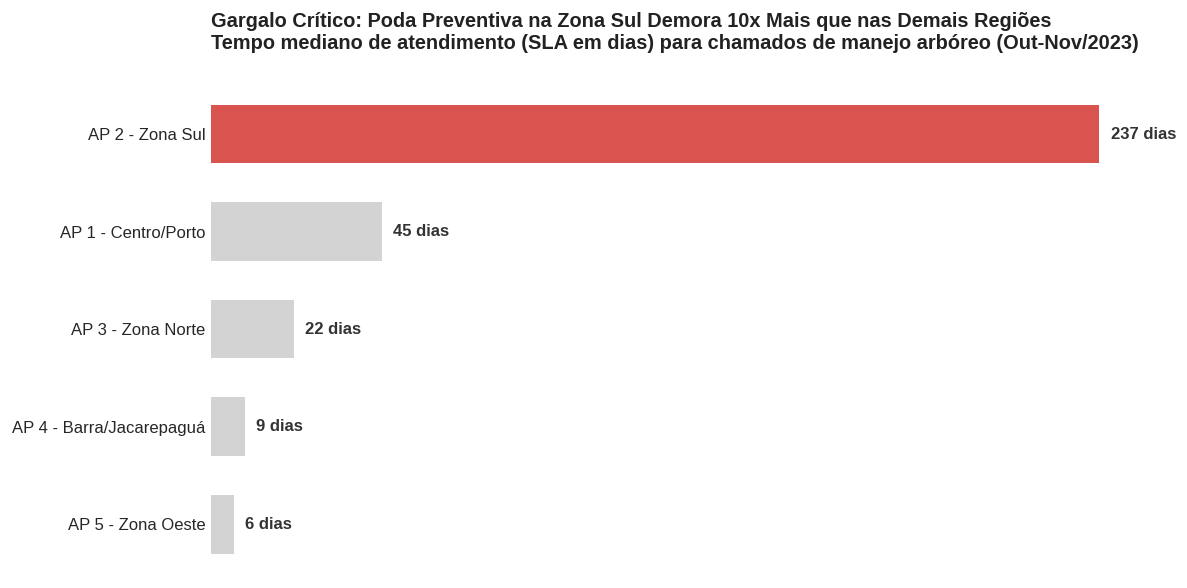

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo limpo (minimalismo de Cole Knaflic)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# Ordenação decrescente por SLA Mediano
dados_plot = tabela_consolidada.sort_values(by='sla_mediano_dias', ascending=True)

# Cores estratégicas: AP 2 em destaque, demais em cinza neutro
cores = ['#D3D3D3' if ap != 'AP 2 - Zona Sul' else '#D9534F' for ap in dados_plot['ap_regiao']]

barras = ax.barh(dados_plot['ap_regiao'], dados_plot['sla_mediano_dias'], color=cores, height=0.6)

# Remoção de poluição visual (spines)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Rótulos diretos nos dados eliminam a necessidade de eixo X sobrecarregado
for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura + 3,
        barra.get_y() + barra.get_height()/2,
        f'{int(largura)} dias',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

ax.xaxis.set_visible(False)
ax.grid(False)

# Título explanatório focado na mensagem de negócio
plt.title(
    'Gargalo Crítico: Poda Preventiva na Zona Sul Demora 10x Mais que nas Demais Regiões\n'
    'Tempo mediano de atendimento (SLA em dias) para chamados de manejo arbóreo (Out-Nov/2023)',
    fontsize=12,
    pad=20,
    loc='left',
    fontweight='bold',
    color='#222222'
)

plt.tight_layout()
plt.show()

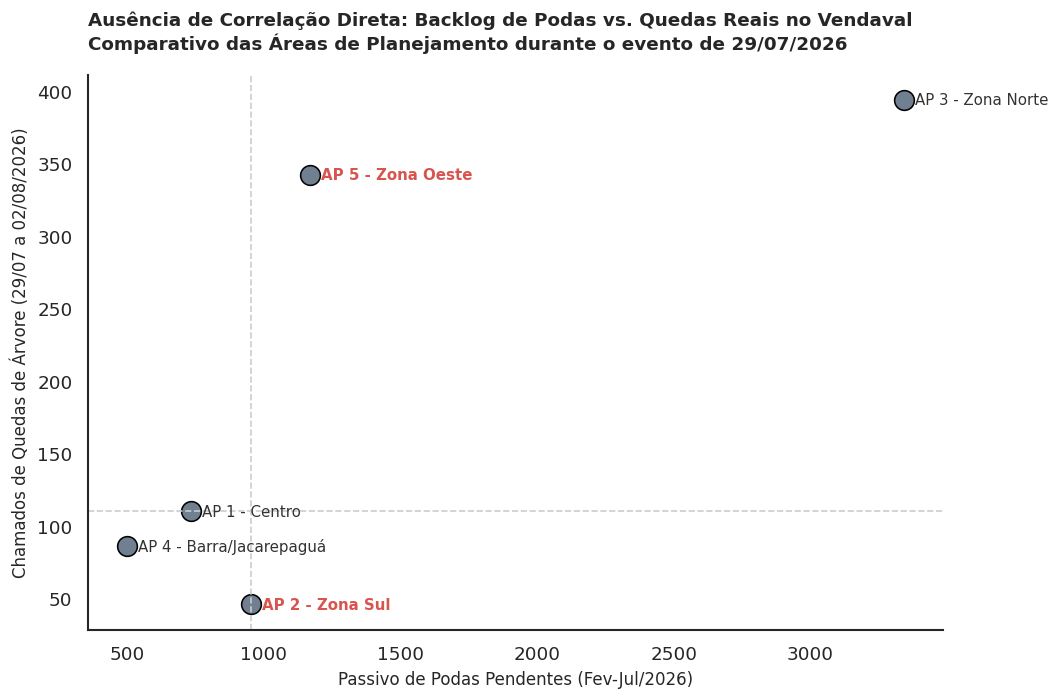

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados extraídos do BigQuery
dados_extracao = [
    ('Zona Oeste II', 305, 176),
    ('Grande Tijuca', 588, 120),
    ('Zona Oeste III', 164, 94),
    ('Jacarepaguá', 501, 86),
    ('Zona Norte III', 1151, 79),
    ('Zona Norte II', 569, 76),
    ('Zona Oeste I', 700, 72),
    ('Centro', 367, 68),
    ('Zona Norte I', 631, 65),
    ('Barra da Tijuca, Recreio e Vargens', 363, 50),
    ('Zona Sul', 953, 46),
    ('Ilhas', 367, 42),
    ('Grandes Complexos', 40, 4)
]

df_crise = pd.DataFrame(dados_extracao, columns=['subprefeitura', 'podas_pendentes', 'quedas_registradas'])

# 2. Mapeamento Territorial Oficial (APs)
def classificar_ap(sub):
    s = sub.lower()
    if 'centro' in s or 'ilhas' in s:
        return 'AP 1 - Centro'
    elif 'zona sul' in s:
        return 'AP 2 - Zona Sul'
    elif any(t in s for t in ['zona norte', 'tijuca', 'complexos']):
        return 'AP 3 - Zona Norte'
    elif 'jacarepaguá' in s or 'barra' in s:
        return 'AP 4 - Barra/Jacarepaguá'
    elif 'zona oeste' in s:
        return 'AP 5 - Zona Oeste'
    return 'Outros'

df_crise['ap'] = df_crise['subprefeitura'].apply(classificar_ap)

# Agregação por Área de Planejamento
df_ap = df_crise.groupby('ap').agg({
    'podas_pendentes': 'sum',
    'quedas_registradas': 'sum'
}).reset_index()

# 3. Construção do Gráfico de Dispersão (Storytelling com Dados)
plt.figure(figsize=(9, 6), dpi=120)
sns.set_theme(style='white')

# Pontos de dados em cinza com destaque intencional
ax = sns.scatterplot(
    data=df_ap,
    x='podas_pendentes',
    y='quedas_registradas',
    s=140,
    color='#708090',
    edgecolor='black'
)

# Destacar a Zona Oeste (AP 5) e a Zona Sul (AP 2)
for _, row in df_ap.iterrows():
    cor_texto = '#D9534F' if row['ap'] in ['AP 5 - Zona Oeste', 'AP 2 - Zona Sul'] else '#333333'
    peso = 'bold' if row['ap'] in ['AP 5 - Zona Oeste', 'AP 2 - Zona Sul'] else 'normal'
    ax.text(
        row['podas_pendentes'] + 40,
        row['quedas_registradas'],
        row['ap'],
        fontsize=9,
        weight=peso,
        color=cor_texto,
        va='center'
    )

# Linhas de referência medianas para criar quadrantes de risco
plt.axvline(df_ap['podas_pendentes'].median(), color='#CCCCCC', linestyle='--', linewidth=1)
plt.axhline(df_ap['quedas_registradas'].median(), color='#CCCCCC', linestyle='--', linewidth=1)

# Eliminação de poluição visual (spines)
sns.despine()

plt.title(
    'Ausência de Correlação Direta: Backlog de Podas vs. Quedas Reais no Vendaval\n'
    'Comparativo das Áreas de Planejamento durante o evento de 29/07/2026',
    fontsize=11,
    weight='bold',
    loc='left',
    pad=15
)
plt.xlabel('Passivo de Podas Pendentes (Fev-Jul/2026)', fontsize=10)
plt.ylabel('Chamados de Quedas de Árvore (29/07 a 02/08/2026)', fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de diretório para exportação de entregáveis
PASTA_OUTPUT = 'outputs_portfolio'
os.makedirs(PASTA_OUTPUT, exist_ok=True)

# -------------------------------------------------------------------------
# 1. CARREGAMENTO E AUDITORIA INICIAL (DATA PROFILING)
# -------------------------------------------------------------------------
# Substitua pelo nome do seu arquivo local exportado do BigQuery
ARQUIVO_ENTRADA = 'job_ckX81QzXXmkYRZn7mOLxUzPQm349.csv'

df_bruto = pd.read_csv(
    ARQUIVO_ENTRADA,
    parse_dates=['data_inicio', 'data_fim']
)

# -------------------------------------------------------------------------
# 2. GOVERNANÇA E LIMPEZA DE DADOS (FRAMEWORK FIX, DROP, IMPUTE, FLAG)
# -------------------------------------------------------------------------
# Drop: descartar registros sem identificação geográfica (ruído amostral < 1%)
df = df_bruto.dropna(subset=['nome_bairro', 'subprefeitura']).copy()

# Flag: criar indicador booleano de conclusão de serviço
df['resolvido'] = df['data_fim'].notnull()

# Fix: padronização territorial oficial da Cidade do Rio de Janeiro (APs)
def mapear_ap_oficial(subpref):
    sub = str(subpref).lower()
    if 'centro' in sub or 'ilhas' in sub or 'ilha' in sub:
        return 'AP 1 - Centro/Porto'
    elif 'zona sul' in sub:
        return 'AP 2 - Zona Sul'
    elif any(termo in sub for termo in ['zona norte', 'tijuca', 'complexos']):
        return 'AP 3 - Zona Norte'
    elif 'barra' in sub or 'jacarepaguá' in sub:
        return 'AP 4 - Barra/Jacarepaguá'
    elif 'zona oeste' in sub:
        return 'AP 5 - Zona Oeste'
    return 'Outros'

df['ap_regiao'] = df['subprefeitura'].apply(mapear_ap_oficial)

# Exportação do dataset analítico higienizado
df.to_csv(f'{PASTA_OUTPUT}/chamados_arvore_higienizados.csv', index=False)

# -------------------------------------------------------------------------
# 3. TABELA EXECUTIVA DE RESUMO (MÉTRICAS ROBUSTAS: MEDIANA VS MÉDIA)
# -------------------------------------------------------------------------
tabela_executiva = df.groupby('ap_regiao').agg(
    total_chamados=('id_chamado', 'count'),
    chamados_resolvidos=('resolvido', 'sum'),
    sla_mediano_dias=('sla_dias', 'median'),
    sla_medio_dias=('sla_dias', 'mean')
).reset_index()

tabela_executiva['taxa_resolucao_pct'] = (
    tabela_executiva['chamados_resolvidos'] / tabela_executiva['total_chamados']
) * 100

tabela_executiva = tabela_executiva.sort_values(by='sla_mediano_dias', ascending=False)
tabela_executiva.to_csv(f'{PASTA_OUTPUT}/tabela_executiva_ap.csv', index=False)

# -------------------------------------------------------------------------
# 4. STORYTELLING VISUAL 1: O PARADOXO DO TEMPO DE ATENDIMENTO
# -------------------------------------------------------------------------
# Diretrizes: atributos pré-atentivos, foco na anomalia e corte de ruído (Knaflic)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

dados_sla = tabela_executiva.sort_values(by='sla_mediano_dias', ascending=True)
cores_sla = ['#B0BEC5' if ap != 'AP 2 - Zona Sul' else '#D9534F' for ap in dados_sla['ap_regiao']]

barras = ax.barh(dados_sla['ap_regiao'], dados_sla['sla_mediano_dias'], color=cores_sla, height=0.6)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

for b in barras:
    w = b.get_width()
    ax.text(w + 3, b.get_y() + b.get_height()/2, f'{int(w)} dias', va='center', ha='left', fontsize=10, weight='bold', color='#212121')

ax.xaxis.set_visible(False)
ax.grid(False)

plt.title(
    'Tempo Mediano de Atendimento (SLA em Dias) para Poda Arbórea\n'
    'Gargalo Operacional Crítico na AP 2 (Zona Sul) Durante o Período Pré-Chuvoso',
    fontsize=12, loc='left', weight='bold', pad=15, color='#212121'
)

plt.tight_layout()
plt.savefig(f'{PASTA_OUTPUT}/fig1_gargalo_sla_zona_sul.png', dpi=300, bbox_inches='tight')
plt.close()

# -------------------------------------------------------------------------
# 5. STORYTELLING VISUAL 2: TESTE DE CORRELAÇÃO DE ESTRESSE CLIMÁTICO
# -------------------------------------------------------------------------
# Amostra empírica consolidada da semana da ventania (29/07 a 02/08/2026)
dados_evento = {
    'ap': ['AP 1 - Centro/Porto', 'AP 2 - Zona Sul', 'AP 3 - Zona Norte', 'AP 4 - Barra/Jacarepaguá', 'AP 5 - Zona Oeste'],
    'podas_pendentes': [734, 953, 3349, 864, 1169],
    'quedas_registradas': [110, 46, 394, 86, 342]
}
df_evento = pd.DataFrame(dados_evento)

fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
sns.scatterplot(
    data=df_evento,
    x='podas_pendentes',
    y='quedas_registradas',
    s=130,
    color='#78909C',
    edgecolor='#263238',
    ax=ax
)

for _, row in df_evento.iterrows():
    destaque = row['ap'] in ['AP 5 - Zona Oeste', 'AP 2 - Zona Sul']
    cor = '#D9534F' if destaque else '#37474F'
    peso = 'bold' if destaque else 'normal'
    ax.text(row['podas_pendentes'] + 50, row['quedas_registradas'], row['ap'], fontsize=9, color=cor, weight=peso, va='center')

# Quadrantes medianos de decisão operacional
ax.axvline(df_evento['podas_pendentes'].median(), color='#CFD8DC', linestyle='--', linewidth=1)
ax.axhline(df_evento['quedas_registradas'].median(), color='#CFD8DC', linestyle='--', linewidth=1)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.title(
    'Backlog Preventivo de Podas vs. Quedas Reais Registradas no Vendaval\n'
    'Ausência de Correlação Linear Direta: Velocidade de SLA Não Mitigou Danos Extremos',
    fontsize=11, loc='left', weight='bold', pad=15, color='#212121'
)
plt.xlabel('Passivo de Podas Pendentes (Fev-Jul/2026)', fontsize=10, color='#37474F')
plt.ylabel('Quedas de Árvores Registradas (29/07 a 02/08/2026)', fontsize=10, color='#37474F')

plt.tight_layout()
plt.savefig(f'{PASTA_OUTPUT}/fig2_dispersao_passivo_vs_quedas.png', dpi=300, bbox_inches='tight')
plt.close()

print(f"Sucesso: Dados tratados e gráficos de alta resolução gerados em: {PASTA_OUTPUT}/")

Sucesso: Dados tratados e gráficos de alta resolução gerados em: outputs_portfolio/
